In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [3]:
# Open file
file = uproot.open("sample_root_files/output_570.root")
# Open events tree
events_tree = file['Events']
# Open EFTFitCoefficients branch:
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [25]:
# Making function that adds weights to the histograms below
def weights(data):
    return [1 / len(data)] * len(data)

In [4]:
elec_n = events_tree['nElectron'].array()
mu_n = events_tree['nMuon'].array()
tau_n = events_tree['nTau'].array()

In [38]:
lepton_n = elec_n + mu_n + tau_n
tri_lepton = lepton_n == 3

In [39]:
eft_coeff_tri_lepton = []
for i,n in enumerate(tri_lepton):                                       
    if n == True:
        eft_coeff_tri_lepton.append(np.argmax(np.abs(eft_coeff[i,1:])) + 1)

In [40]:
def interesting_coeff(data, percent_min, percent_max):
    percent_and_index = []
    
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if percent_min == percent_max: # Just to avoid errors if we are trying to find a specific percentage
            if coeff_percentage == percent_min:
               percent_and_index.append([round(coeff_percentage*100,7), i]) 
        elif (coeff_percentage > percent_min) and (coeff_percentage <= percent_max): # finds values such that percent_min < value <= percent_max
            percent_and_index.append([round(coeff_percentage*100,7), i])
    
           
    percent_and_index = np.array(percent_and_index)
    indices = np.argsort(percent_and_index[:,0])                    # This tells me the order of the rows
    percent_and_index_ordered = percent_and_index[indices][::-1] # This sorts the rows based on the indices and [::-1] makes it go in descending order
    
    for i in range(len(percent_and_index_ordered)):
        a = print(f'The pair {name_combinations[int(percent_and_index_ordered[i,1])]} with index {int(percent_and_index_ordered[i,1])} has {percent_and_index_ordered[i,0]}%')

    return a

In [41]:
interesting_coeff(eft_coeff_tri_lepton,0.05,1)

The pair ['ctG', 'SM'] with index 36 has 45.1240376%
The pair ['cQq11', 'cQq13'] with index 480 has 16.3387511%
The pair ['ctG', 'ctG'] with index 44 has 12.8314799%
The pair ['ctq1', 'ctq1'] with index 299 has 7.3994867%


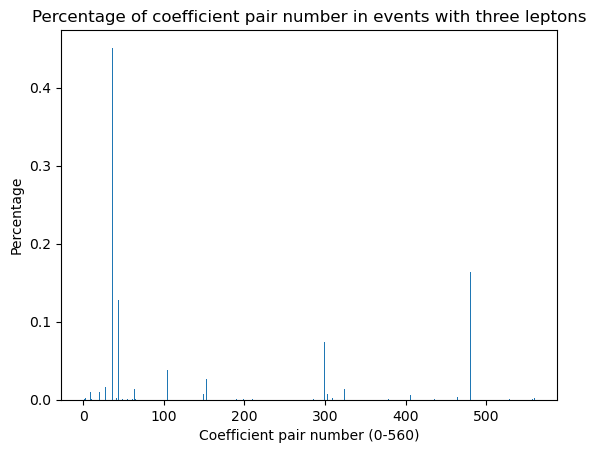

2338

In [46]:
plt.hist(eft_coeff_tri_lepton, bins = 500, weights = weights(eft_coeff_tri_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in events with three leptons')
plt.show()
len(eft_coeff_tri_lepton)

In [67]:
elec_charge = events_tree['Electron_charge'].array()
mu_charge = events_tree['Muon_charge'].array()
tau_charge = events_tree['Tau_charge'].array()

In [84]:
def two_leptons_same_charge(data):
    events_two_leptons_same_charge = []
    for i in range(len(data)):
        if (np.count_nonzero(data[i] == 1) == 2) or (np.count_nonzero(data[i] == -1) == 2):
            events_two_leptons_same_charge.append(i)
    return events_two_leptons_same_charge

In [87]:
all_events_with_two_leptons_same_charge = list(set(two_leptons_same_charge(elec_charge) + two_leptons_same_charge(mu_charge) + two_leptons_same_charge(tau_charge)))

IOStream.flush timed out


In [90]:
eft_coeff_same_charge_leptons = []
for i, n in enumerate(all_events_with_two_leptons_same_charge):
    eft_coeff_same_charge_leptons.append(np.argmax(np.abs(eft_coeff[n,1:])) + 1)

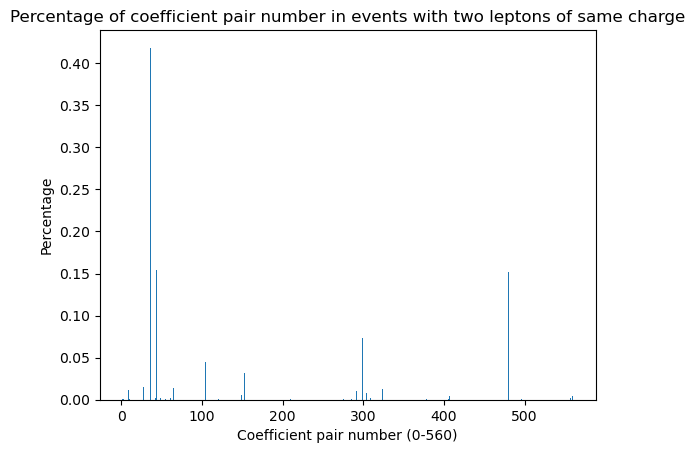

The pair ['ctG', 'SM'] with index 36 has 41.8468964%
The pair ['ctG', 'ctG'] with index 44 has 15.4569892%
The pair ['cQq11', 'cQq13'] with index 480 has 15.2263563%
The pair ['ctq1', 'ctq1'] with index 299 has 7.2916667%


65472

In [117]:
plt.hist(eft_coeff_same_charge_leptons, bins = 500, weights = weights(eft_coeff_same_charge_leptons))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in events with two leptons of same charge')
plt.show()
interesting_coeff(eft_coeff_same_charge_leptons,0.05,1)
len(eft_coeff_same_charge_leptons)

In [98]:
def two_leptons_opposite_charge(data):
    events_two_leptons_opposite_charge = []
    for i in range(len(data)):
        if (np.count_nonzero(data[i] == 1) == 1) and (np.count_nonzero(data[i] == -1) == 1):
            events_two_leptons_opposite_charge.append(i)
    return events_two_leptons_opposite_charge

In [113]:
all_events_with_two_leptons_opposite_charge = list(set(two_leptons_opposite_charge(elec_charge) + two_leptons_opposite_charge(mu_charge) + two_leptons_opposite_charge(tau_charge)))
# This line works because the outputs are lists. If they were numpy arrays, they would actually add! We would need to use 

In [114]:
eft_coeff_opposite_charge_leptons = []
for i, n in enumerate(all_events_with_two_leptons_opposite_charge):
    eft_coeff_opposite_charge_leptons.append(np.argmax(np.abs(eft_coeff[n,1:])) + 1)

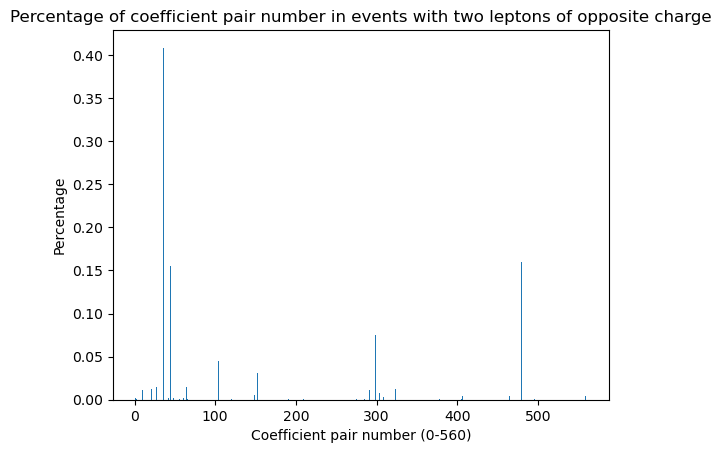

The pair ['ctG', 'SM'] with index 36 has 40.8342803%
The pair ['cQq11', 'cQq13'] with index 480 has 15.9708222%
The pair ['ctG', 'ctG'] with index 44 has 15.4833034%
The pair ['ctq1', 'ctq1'] with index 299 has 7.492394%


27281

In [116]:
plt.hist(eft_coeff_opposite_charge_leptons, bins = 500, weights = weights(eft_coeff_opposite_charge_leptons))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in events with two leptons of opposite charge')
plt.show()
interesting_coeff(eft_coeff_opposite_charge_leptons,0.05,1)
len(eft_coeff_opposite_charge_leptons)